# **1. Data Quality Assesment**

In [315]:
# Importing libraries
import pandas as pd
import numpy as np
from datetime import datetime
import os
import pprint
import missingno as mno

In [316]:
# Reading the dataset
artwork_data = pd.read_csv('https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artwork_data.csv')
artist_data = pd.read_csv('https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artist_data.csv')

/tmp/ipython-input-3758514550.py:2: DtypeWarning: Columns (9,13) have mixed types. Specify dtype option on import or set low_memory=False.
  artwork_data = pd.read_csv('https://raw.githubusercontent.com/omar-mohamed-azab/Polimi-Data-and-Information-Quality-Project/refs/heads/main/Dataset/artwork_data.csv')


In [317]:
artwork_data

,id,accession_number,artist,artistRole,artistId,title,dateText,medium,creditLine,year,acquisitionYear,dimensions,width,height,depth,units,inscription,thumbnailCopyright,thumbnailUrl,url
0,1035,A00001,"Blake, Robert",artist,38,A Figure Bowing before a Seated Old Man with h...,date not known,"Watercolour, ink, chalk and graphite on paper....",Presented by Mrs John Richmond 1922,NaN,1922.0,support: 394 x 419 mm,394,419.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-a-fi...
1,1036,A00002,"Blake, Robert",artist,38,"Two Drawings of Frightened Figures, Probably f...",date not known,Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 311 x 213 mm,311,213.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-two-...
2,1037,A00003,"Blake, Robert",artist,38,The Preaching of Warning. Verso: An Old Man En...,?c.1785,Graphite on paper. Verso: graphite on paper,Presented by Mrs John Richmond 1922,1785.0,1922.0,support: 343 x 467 mm,343,467.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...
3,1038,A00004,"Blake, Robert",artist,38,Six Drawings of Figures with Outstretched Arms,date not known,Graphite on paper,Presented by Mrs John Richmond 1922,NaN,1922.0,support: 318 x 394 mm,318,394.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-six-...
4,1039,A00005,"Blake, William",artist,39,The Circle of the Lustful: Francesca da Rimini...,"1826–7, reprinted 1892",Line engraving on paper,Purchased with the assistance of a special gra...,1826.0,1919.0,image: 243 x 335 mm,243,335.0,NaN,mm,NaN,NaN,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,122960,T13865,"P-Orridge, Genesis",artist,16646,Larvae (from Tampax Romana),1975,"Perspex, Wood, hairpiece, tampon and human blood",Transferred from Tate Archive 2012,1975,2013.0,object: 305 x 305 x 135 mm,305,305.0,135.0,mm,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/p-orridge-...
69197,122961,T13866,"P-Orridge, Genesis",artist,16646,Living Womb (from Tampax Romana),1976,"Wood, Perspex, plastic, photograph on paper, t...",Transferred from Tate Archive 2012,1976,2013.0,object: 305 x 305 x 135 mm,305,305.0,135.0,mm,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/p-orridge-...
69198,121181,T13867,"Hatoum, Mona",artist,2365,Present Tense,1996,Soap and glass beads,Presented by Tate Members 2013,1996,2013.0,displayed: 45 x 2410 x 2990 mm,45,2410.0,2990.0,mm,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/hatoum-pre...
69199,112306,T13868,"Creed, Martin",artist,2760,Work No. 227: The lights going on and off,2000,Gallery lighting,"Purchased with funds provided by Tate Members,...",2000,2013.0,Overall display dimensions variable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://www.tate.org.uk/art/artworks/creed-work...


In [318]:
artist_data

,id,name,gender,dates,yearOfBirth,yearOfDeath,placeOfBirth,placeOfDeath,url
0,10093,"Abakanowicz, Magdalena",Female,born 1930,1930.0,NaN,Polska,NaN,http://www.tate.org.uk/art/artists/magdalena-a...
1,0,"Abbey, Edwin Austin",Male,1852–1911,1852.0,1911.0,"Philadelphia, United States","London, United Kingdom",http://www.tate.org.uk/art/artists/edwin-austi...
2,2756,"Abbott, Berenice",Female,1898–1991,1898.0,1991.0,"Springfield, United States","Monson, United States",http://www.tate.org.uk/art/artists/berenice-ab...
3,1,"Abbott, Lemuel Francis",Male,1760–1803,1760.0,1803.0,"Leicestershire, United Kingdom","London, United Kingdom",http://www.tate.org.uk/art/artists/lemuel-fran...
4,622,"Abrahams, Ivor",Male,born 1935,1935.0,NaN,"Wigan, United Kingdom",NaN,http://www.tate.org.uk/art/artists/ivor-abraha...
...,...,...,...,...,...,...,...,...,...
3527,12542,"Zorio, Gilberto",Male,born 1944,1944.0,NaN,"Andorno Micca, Italia",NaN,http://www.tate.org.uk/art/artists/gilberto-zo...
3528,2186,"Zox, Larry",Male,born 1936,1936.0,NaN,"Des Moines, United States",NaN,http://www.tate.org.uk/art/artists/larry-zox-2186
3529,621,"Zuccarelli, Francesco",Male,1702–1788,1702.0,1788.0,Italia,Firenze,http://www.tate.org.uk/art/artists/francesco-z...
3530,2187,"Zuloaga, Ignacio",Male,1870–1945,1870.0,1945.0,España,España,http://www.tate.org.uk/art/artists/ignacio-zul...


In [319]:
# Printing the dimesnsions of the data
print('dimensions of artwork data:', artwork_data.shape)
print('dimensions of artist data:', artist_data.shape)

dimensions of artwork data: (69201, 20)
dimensions of artist data: (3532, 9)


In [320]:
# Showing the type of columns
artwork_data.dtypes

,0
id,int64
accession_number,object
artist,object
artistRole,object
artistId,int64
title,object
dateText,object
medium,object
creditLine,object
year,object


In [321]:
# Checking for duplicates
artwork_data.duplicated().any()

np.False_

In [322]:
# Checking null values
artwork_data.isnull()

,id,accession_number,artist,artistRole,artistId,title,dateText,medium,creditLine,year,acquisitionYear,dimensions,width,height,depth,units,inscription,thumbnailCopyright,thumbnailUrl,url
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False
1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
69197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
69198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
69199,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,True,True,True,True,False


In [323]:
# Check the number of null values in each column
artwork_data.isnull().sum()

,0
id,0
accession_number,0
artist,0
artistRole,0
artistId,0
title,0
dateText,0
medium,6384
creditLine,3
year,5378


In [324]:
# Number of nit Null values in each column
artwork_data.notnull().sum()

,0
id,69201
accession_number,69201
artist,69201
artistRole,69201
artistId,69201
title,69201
dateText,69201
medium,62817
creditLine,69198
year,63823


In [325]:
# Total number of Nulls in the data
artwork_data.isnull().sum().sum()

np.int64(219596)

In [326]:
# Total number of cells that are not Null
Not_Null = artwork_data.notnull().sum().sum()
Not_Null

np.int64(1164424)

In [327]:
# Total number of cells in the data
TOT = artwork_data.shape[0]*artwork_data.shape[1]
TOT

1384020

<Axes: >

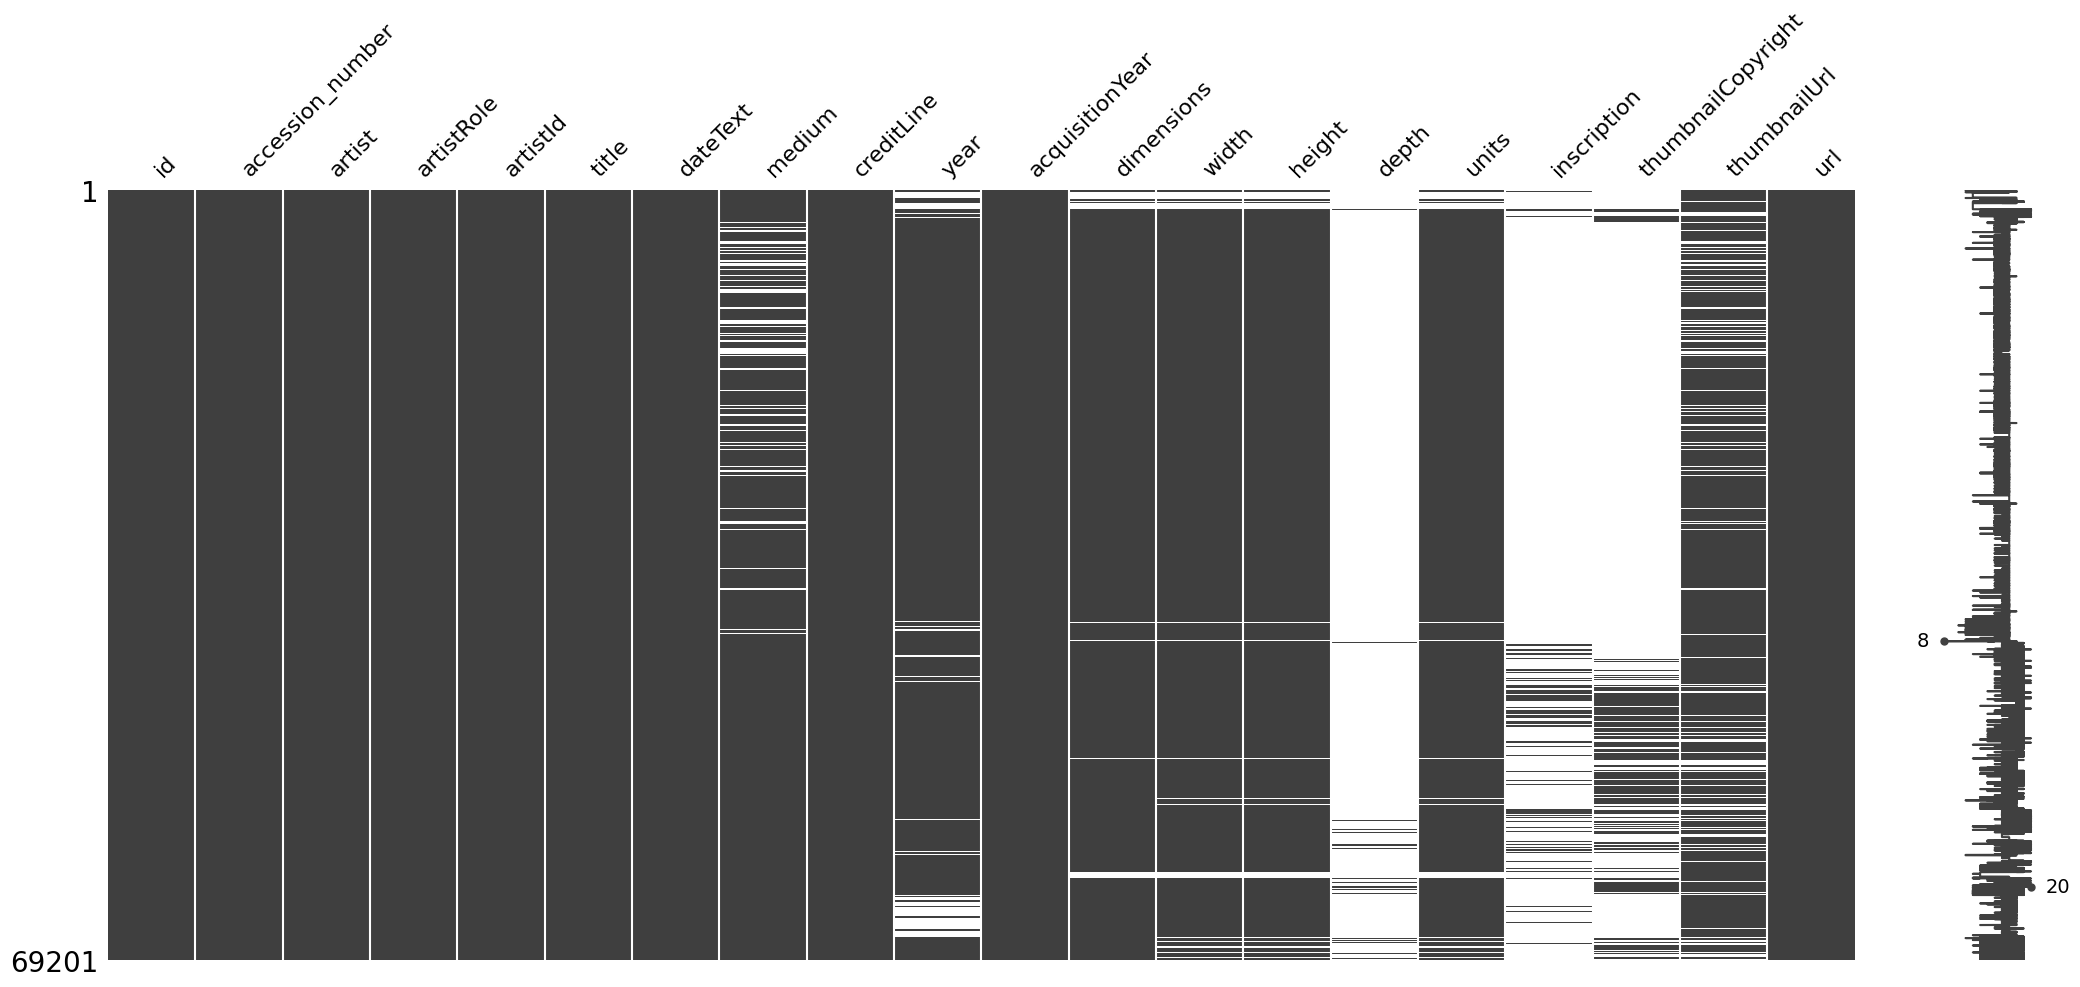

In [328]:
mno.matrix(artwork_data)

In [329]:
# Evaluating Completeness
Completeness = Not_Null/TOT
Completeness = '{0:.1f}%'.format(Completeness*100)
print(Completeness)

84.1%


# **2. Data Transformation & Standardization**

In [330]:
# Getting information about each column
artwork_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69201 entries, 0 to 69200
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  69201 non-null  int64  
 1   accession_number    69201 non-null  object 
 2   artist              69201 non-null  object 
 3   artistRole          69201 non-null  object 
 4   artistId            69201 non-null  int64  
 5   title               69201 non-null  object 
 6   dateText            69201 non-null  object 
 7   medium              62817 non-null  object 
 8   creditLine          69198 non-null  object 
 9   year                63823 non-null  object 
 10  acquisitionYear     69156 non-null  float64
 11  dimensions          66768 non-null  object 
 12  width               65860 non-null  object 
 13  height              65860 non-null  object 
 14  depth               2514 non-null   float64
 15  units               65860 non-null  object 
 16  insc

In [331]:
# Dropping redundant columns
artwork_data = artwork_data.drop(['id','width', 'height', 'depth', 'units'], axis =1)

In [332]:
# Renaming columns
artwork_data = artwork_data.rename(columns = {'accession_number':'Accession Number','artist': 'Artist','artistRole':'Artist Role','artistId':'Artist ID', 'title': 'Title','dateText': 'Date', 'medium': 'Medium', 'creditLine': 'Credit Line', 'year':'Year', 'acquisitionYear': 'Acquisition Year', 'dimensions': 'Dimensions','inscription': 'Inscription' ,'thumbnailCopyright': 'Thumbnail Copyright', 'thumbnailUrl': 'Thumbnail URL', 'url': 'URL'})

In [333]:
# Data Standardization
# artwork_data['Title'] = artwork_data['Title'].str.replace(r'^\?', '', regex=True)
# artwork_data['Title'] = artwork_data['Title'].replace('[blank]','Title Not Known')
# artwork_data['Title'] = artwork_data['Title'].replace('Blank','Title Not Known')
artwork_data['Title'] = artwork_data['Title'].replace('[title not known]','Title Not Known')

artwork_data['Year'] = artwork_data['Year'].replace('no date','Date Not Known')

artwork_data['Date'] = artwork_data['Date'].replace('date not known','Date Not Known')
artwork_data['Date'] = artwork_data['Date'].replace('no date','Date Not Known')
artwork_data['Date'] = artwork_data['Date'].str.replace(r'\?', '', regex=True)

artwork_data['Artist'] = artwork_data['Artist'].str.replace(r'^\?', '', regex=True)


# **3. Error Detection and Correction**

In [334]:
# Filling empty cells
artwork_data['Medium'] = artwork_data['Medium'].fillna('Not Mentioned')

In [335]:
artwork_data['Dimensions'] = artwork_data['Dimensions'].fillna('Not Mentioned')

In [336]:
artwork_data['Inscription'] = artwork_data['Inscription'].fillna('None')

In [337]:
artwork_data['Thumbnail Copyright'] = artwork_data['Thumbnail Copyright'].fillna('None')

In [338]:
artwork_data['Credit Line'] = artwork_data['Credit Line'].fillna('None')

In [339]:
artwork_data['Thumbnail URL'] = artwork_data['Thumbnail URL'].fillna('None')

In [340]:
artwork_data['Acquisition Year'] = artwork_data['Acquisition Year'].fillna('Date Not Known')

In [341]:
artwork_data['Year'] = artwork_data['Year'].fillna('Date Not Known')

<Axes: >

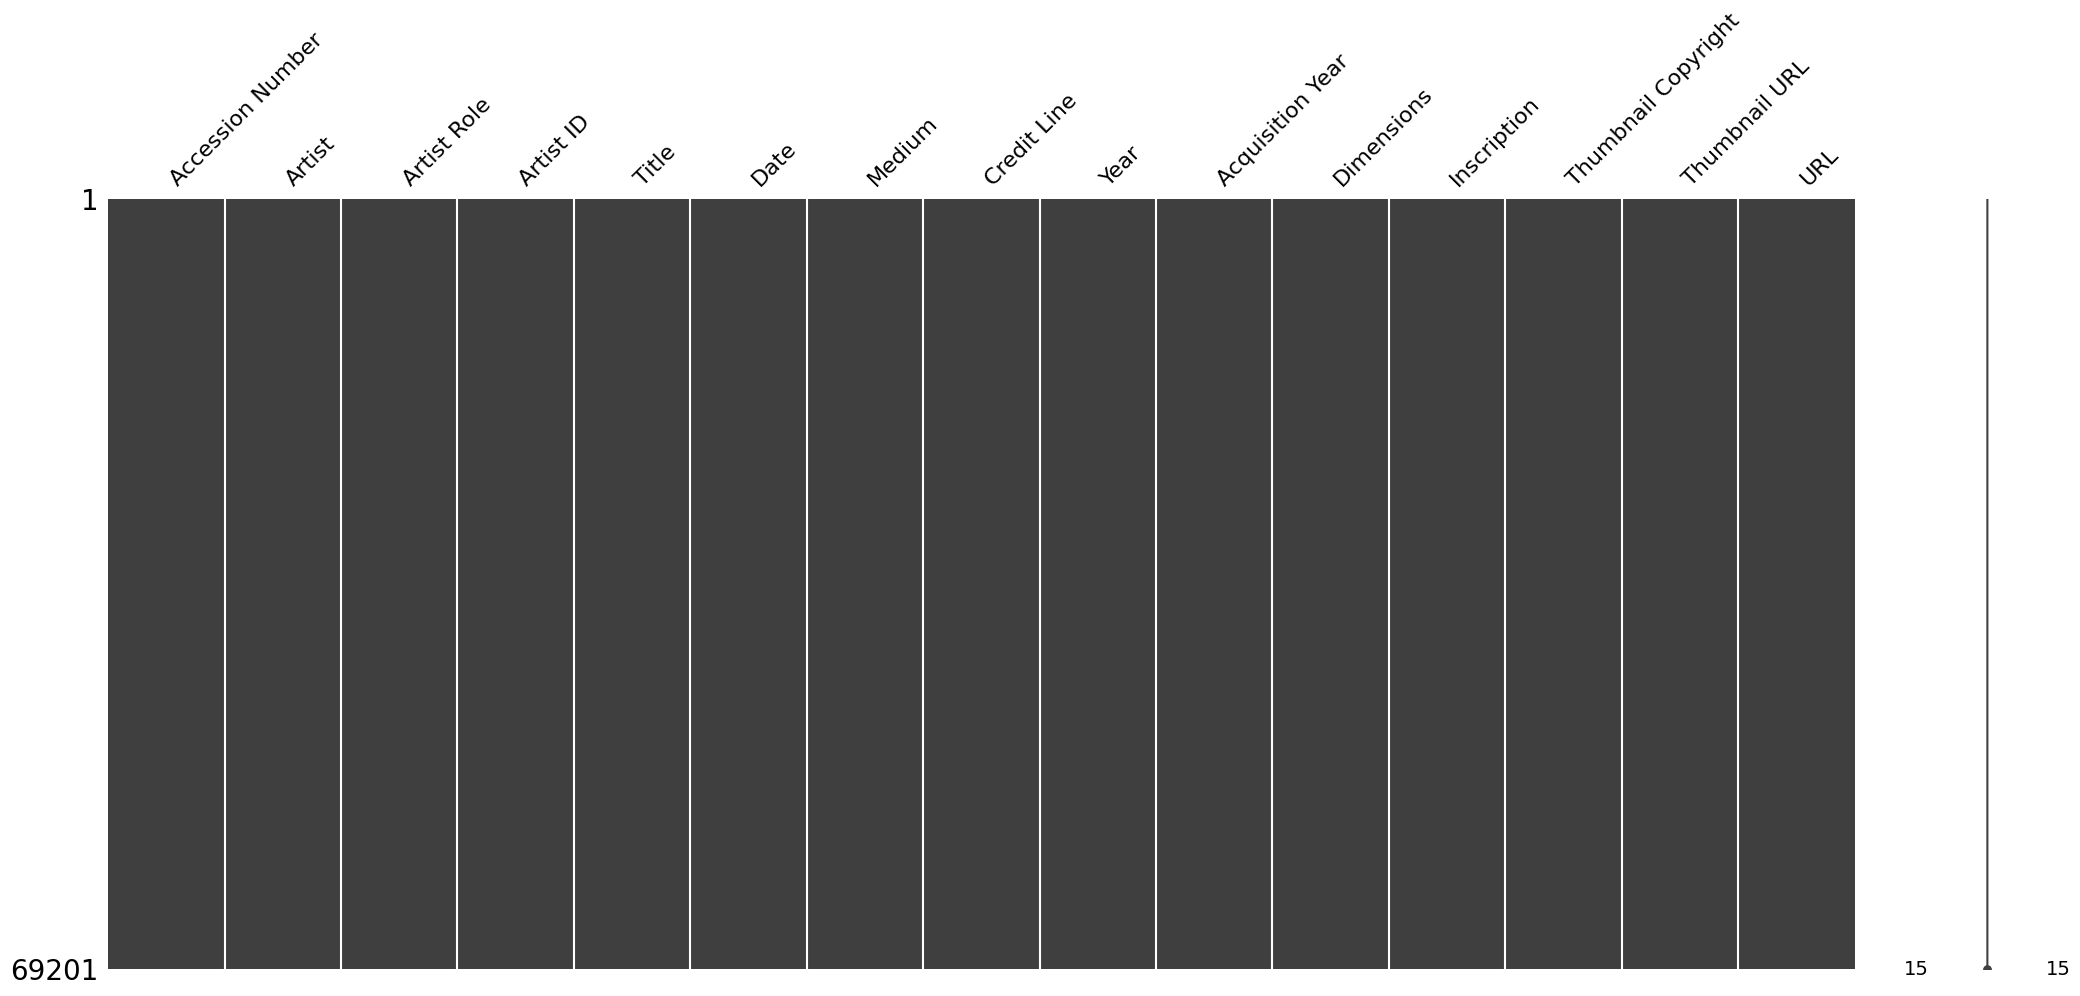

In [342]:
mno.matrix(artwork_data)

# **4. Data Deduplication and Similarity Detection**

In [343]:
# Grouping by Accession Number to check for duplicates
artwork_data.groupby('Accession Number').size()

,0
Accession Number,
A00001,1
A00002,1
A00003,1
A00004,1
A00005,1
...,...
T13865,1
T13866,1
T13867,1


In [344]:
duplicates_1 = artwork_data.groupby(['Artist ID', 'Title']).size().reset_index(name='count')
duplicates_1.to_csv('duplicates_1.csv', index=False, encoding='utf_8')

In [345]:
duplicates_2 = artwork_data.groupby(['Artist ID', 'Title', 'Date']).size().reset_index(name='count')
duplicates_2.to_csv('duplicates_2.csv', index = False, encoding = 'utf_8')

In [346]:
test = artwork_data.drop(['Accession Number', 'Inscription', 'Thumbnail Copyright', 'Thumbnail URL'], axis =1)
test.duplicated().any()

np.False_

In [347]:
all_duplicates = test[test.duplicated(keep=False)]
row_counts = test.groupby(list(test.columns)).size().reset_index(name='duplicate_count')
all_duplicates_with_counts = pd.merge(all_duplicates, row_counts, on=list(test.columns), how='left')
all_duplicates_with_counts.to_csv('all_duplicates.csv', index=False, encoding='utf_8')

In [348]:
# Exporting dataframe into a .csv file
artwork_data.to_csv('artwork_data_cleaned.csv', index = False, encoding = 'utf_8_sig')

In [349]:
# !pip install recordlinkage

In [350]:
# # Finding Candidate Pairs for Record Linkage
# import recordlinkage
# indexer = recordlinkage.Index()
# # Blocking on multiple columns to create smaller blocks and reduce candidate pairs
# indexer.block(['Artist', 'Artist ID', 'Artist Role', 'Title', 'Year','Acquisition Year'])
# candidate_links = indexer.index(artwork_data)
# print(len(candidate_links))
# candidate_links

In [351]:
# indexer = recordlinkage.index.SortedNeighbourhood(on = 'Artist', window = 5)
# candidate_links = indexer.index(artwork_data)
# print(len(candidate_links))
# candidate_links

# **5. Final Data Quality Assesment**

In [352]:
artwork_data

,Accession Number,Artist,Artist Role,Artist ID,Title,Date,Medium,Credit Line,Year,Acquisition Year,Dimensions,Inscription,Thumbnail Copyright,Thumbnail URL,URL
0,A00001,"Blake, Robert",artist,38,A Figure Bowing before a Seated Old Man with h...,Date Not Known,"Watercolour, ink, chalk and graphite on paper....",Presented by Mrs John Richmond 1922,Date Not Known,1922.0,support: 394 x 419 mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-a-fi...
1,A00002,"Blake, Robert",artist,38,"Two Drawings of Frightened Figures, Probably f...",Date Not Known,Graphite on paper,Presented by Mrs John Richmond 1922,Date Not Known,1922.0,support: 311 x 213 mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-two-...
2,A00003,"Blake, Robert",artist,38,The Preaching of Warning. Verso: An Old Man En...,c.1785,Graphite on paper. Verso: graphite on paper,Presented by Mrs John Richmond 1922,1785.0,1922.0,support: 343 x 467 mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...
3,A00004,"Blake, Robert",artist,38,Six Drawings of Figures with Outstretched Arms,Date Not Known,Graphite on paper,Presented by Mrs John Richmond 1922,Date Not Known,1922.0,support: 318 x 394 mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-six-...
4,A00005,"Blake, William",artist,39,The Circle of the Lustful: Francesca da Rimini...,"1826–7, reprinted 1892",Line engraving on paper,Purchased with the assistance of a special gra...,1826.0,1919.0,image: 243 x 335 mm,None,None,http://www.tate.org.uk/art/images/work/A/A00/A...,http://www.tate.org.uk/art/artworks/blake-the-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,T13865,"P-Orridge, Genesis",artist,16646,Larvae (from Tampax Romana),1975,"Perspex, Wood, hairpiece, tampon and human blood",Transferred from Tate Archive 2012,1975,2013.0,object: 305 x 305 x 135 mm,None,None,None,http://www.tate.org.uk/art/artworks/p-orridge-...
69197,T13866,"P-Orridge, Genesis",artist,16646,Living Womb (from Tampax Romana),1976,"Wood, Perspex, plastic, photograph on paper, t...",Transferred from Tate Archive 2012,1976,2013.0,object: 305 x 305 x 135 mm,None,None,None,http://www.tate.org.uk/art/artworks/p-orridge-...
69198,T13867,"Hatoum, Mona",artist,2365,Present Tense,1996,Soap and glass beads,Presented by Tate Members 2013,1996,2013.0,displayed: 45 x 2410 x 2990 mm,None,None,None,http://www.tate.org.uk/art/artworks/hatoum-pre...
69199,T13868,"Creed, Martin",artist,2760,Work No. 227: The lights going on and off,2000,Gallery lighting,"Purchased with funds provided by Tate Members,...",2000,2013.0,Overall display dimensions variable,None,None,None,http://www.tate.org.uk/art/artworks/creed-work...


In [353]:
# Printing the dimesnsions of the data
print('dimensions of artwork data:', artwork_data.shape)

dimensions of artwork data: (69201, 15)
dimensions of artist data: (3532, 9)


In [354]:
# Showing the type of columns
artwork_data.dtypes

,0
Accession Number,object
Artist,object
Artist Role,object
Artist ID,int64
Title,object
Date,object
Medium,object
Credit Line,object
Year,object
Acquisition Year,object


In [355]:
# Checking for duplicates
artwork_data.duplicated().any()

np.False_

In [356]:
# Checking null values
artwork_data.isnull()

,Accession Number,Artist,Artist Role,Artist ID,Title,Date,Medium,Credit Line,Year,Acquisition Year,Dimensions,Inscription,Thumbnail Copyright,Thumbnail URL,URL
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69196,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69197,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69198,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
69199,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [357]:
# Check the number of null values in each column
artwork_data.isnull().sum()

,0
Accession Number,0
Artist,0
Artist Role,0
Artist ID,0
Title,0
Date,0
Medium,0
Credit Line,0
Year,0
Acquisition Year,0


In [358]:
# Number of nit Null values in each column
artwork_data.notnull().sum()

,0
Accession Number,69201
Artist,69201
Artist Role,69201
Artist ID,69201
Title,69201
Date,69201
Medium,69201
Credit Line,69201
Year,69201
Acquisition Year,69201


In [359]:
# Total number of Nulls in the data
artwork_data.isnull().sum().sum()

np.int64(0)

In [360]:
# Total number of cells that are not Null
Not_Null = artwork_data.notnull().sum().sum()
Not_Null

np.int64(1038015)

In [361]:
# Total number of cells in the data
TOT = artwork_data.shape[0]*artwork_data.shape[1]
TOT

1038015

In [362]:
# Evaluating Completeness
Completeness = Not_Null/TOT
Completeness = '{0:.1f}%'.format(Completeness*100)
print(Completeness)

100.0%
